# 2. Visualize indivisual circuits dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## 1. Listing the follow-line circuits
1. Simple Circuit
2. Montreal Circuit
3. Montmelo Circuit
4. Nurburgring Circuit

In [13]:
# CONSTANT
RAW_BASE_DIR = ""
CIRCUIT_LIST = [
    "simple_circuit",
    "montreal_circuit",
    "montmelo_circuit",
    "nurburgring_circuit"
]

### Load datasets

In [14]:
# simple circuit
df_simple_circuit = pd.read_csv(os.path.join(RAW_BASE_DIR,CIRCUIT_LIST[0],f"{CIRCUIT_LIST[0]}-labels.csv"))

In [15]:
# montreal circuit
df_montreal_circuit = pd.read_csv(os.path.join(RAW_BASE_DIR,CIRCUIT_LIST[1],f"{CIRCUIT_LIST[1]}-labels.csv"))

In [16]:
# montmelo circuit
df_montmelo_circuit = pd.read_csv(os.path.join(RAW_BASE_DIR,CIRCUIT_LIST[2],f"{CIRCUIT_LIST[2]}-labels.csv"))

In [17]:
# nurburgring circuit
df_nurburgring_circuit = pd.read_csv(os.path.join(RAW_BASE_DIR,CIRCUIT_LIST[3],f"{CIRCUIT_LIST[3]}-labels.csv"))

In [18]:
# angular velocity describe
print(df_simple_circuit["w"].describe())
print(df_montreal_circuit["w"].describe())
print(df_montmelo_circuit["w"].describe())
print(df_nurburgring_circuit["w"].describe())

count    5356.000000
mean       -0.101827
std         0.475224
min        -1.630480
25%        -0.330768
50%        -0.090770
75%         0.062150
max         1.730520
Name: w, dtype: float64
count    14651.000000
mean        -0.035065
std          0.298968
min         -2.500000
25%         -0.066270
50%         -0.001570
75%          0.012000
max          1.847710
Name: w, dtype: float64
count    10001.000000
mean        -0.055658
std          0.435558
min         -2.500000
25%         -0.225190
50%         -0.009650
75%          0.047680
max          2.500000
Name: w, dtype: float64
count    8156.000000
mean       -0.063677
std         0.512451
min        -2.500000
25%        -0.132770
50%         0.003135
75%         0.068730
max         2.135370
Name: w, dtype: float64


In [19]:
# linear velocity describe
print(df_simple_circuit["v"].describe())
print(df_montreal_circuit["v"].describe())
print(df_montmelo_circuit["v"].describe())
print(df_nurburgring_circuit["v"].describe())

count    5356.000000
mean        5.033186
std         1.461997
min         4.000000
25%         4.000000
50%         4.000000
75%         6.168000
max         8.000000
Name: v, dtype: float64
count    14651.000000
mean         6.057057
std          1.510393
min          4.000000
25%          4.000000
50%          6.506667
75%          7.432000
max          8.000000
Name: v, dtype: float64
count    10001.000000
mean         4.986425
std          1.284774
min          4.000000
25%          4.000000
50%          4.000000
75%          6.274667
max          8.000000
Name: v, dtype: float64
count    8156.000000
mean        4.955495
std         1.356774
min         4.000000
25%         4.000000
50%         4.000000
75%         6.080000
max         8.000000
Name: v, dtype: float64


In [20]:
# Step 3: Categorize angular velocity (w) into 5 categories
def categorize_w(w):
    if w < -1.0:
        return "sharp_right"
    elif w < -0.05:
        return "right"
    elif w <= 0.05:
        return "straight"
    elif w <= 1.0:
        return "left"
    else:
        return "sharp_left"

In [21]:
df_simple_circuit["w_category"] = df_simple_circuit["w"].apply(categorize_w)
df_montreal_circuit["w_category"] = df_montreal_circuit["w"].apply(categorize_w)
df_montmelo_circuit["w_category"] = df_montmelo_circuit["w"].apply(categorize_w)
df_nurburgring_circuit["w_category"] = df_nurburgring_circuit["w"].apply(categorize_w)

In [22]:
circuit_dfs = {
    "simple_circuit": df_simple_circuit,
    "montreal_circuit": df_montreal_circuit,
    "montmelo_circuit": df_montmelo_circuit,
    "nurburgring_circuit": df_nurburgring_circuit
}

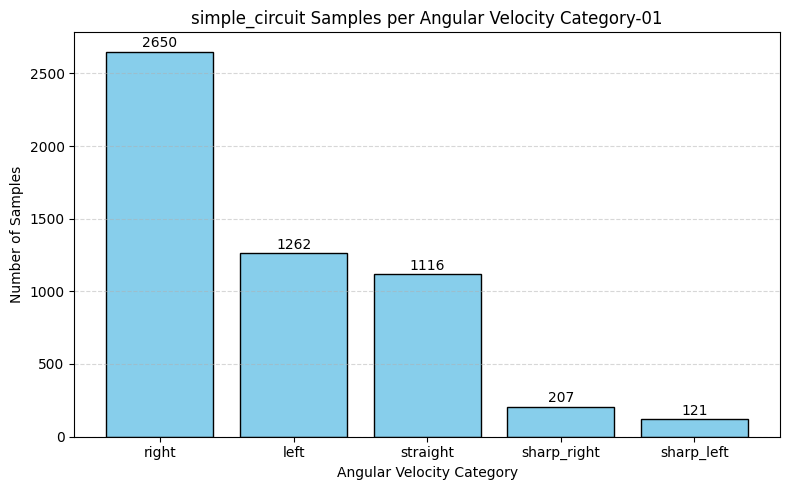

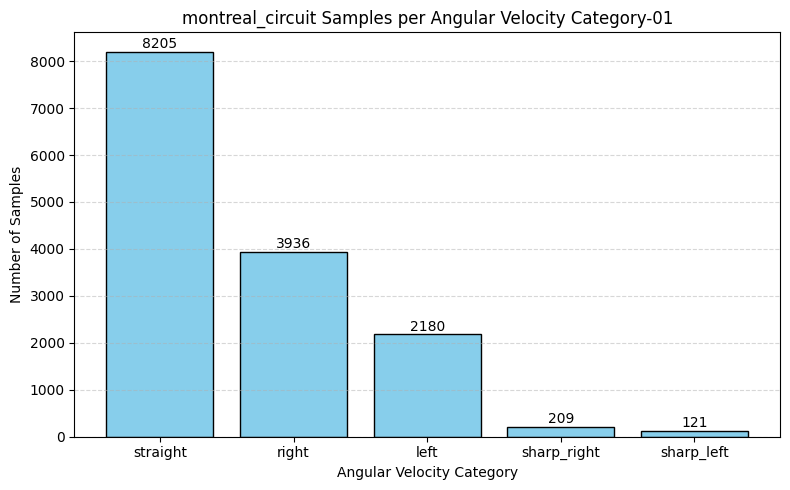

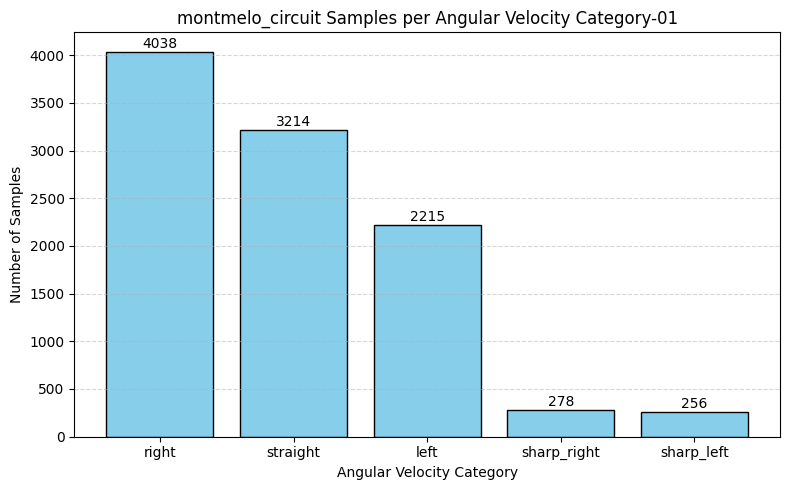

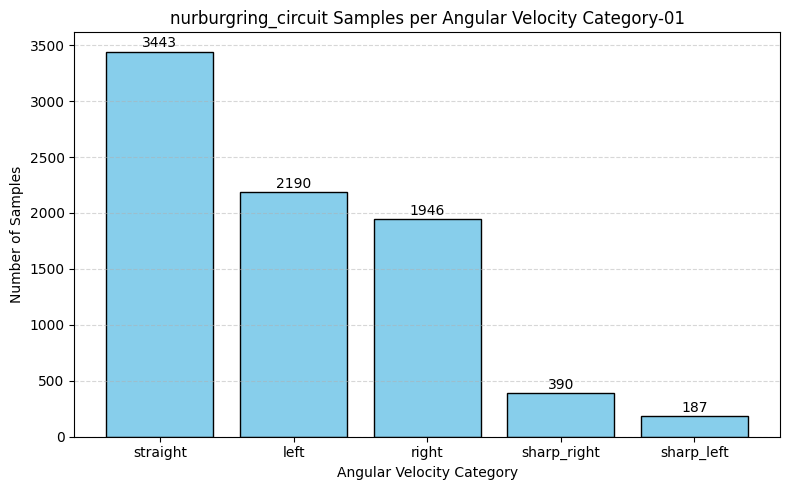

In [23]:
os.makedirs("visualization-images",exist_ok=True)
for circuit_name in CIRCUIT_LIST:
    tmp_df = circuit_dfs[circuit_name]
    category_counts = tmp_df['w_category'].value_counts()
    # print("value_counts ",category_counts)
    
    # Plot
    plt.figure(figsize=(8, 5))
    bars = plt.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')
    
    # Add counts above bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)
    
    # Labels and title
    plt.title(f"{circuit_name} Samples per Angular Velocity Category-01")
    plt.xlabel("Angular Velocity Category")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.savefig(f"visualization-images/{circuit_name}-angular_velocity_category_1.png")
    plt.show()

In [ ]:
def categorize_v(v):
    if v <= 6.5:
        return "slow"
    elif v <= 8.0:
        return "moderate"
    elif v <= 9.5:
        return "fast"
    else:
        return "very_fast"

In [ ]:
df_simple_circuit["v_category"] = df_simple_circuit["v"].apply(categorize_v)
df_montreal_circuit["v_category"] = df_montreal_circuit["v"].apply(categorize_v)
df_montmelo_circuit["v_category"] = df_montmelo_circuit["v"].apply(categorize_v)
df_nurburgring_circuit["v_category"] = df_nurburgring_circuit["v"].apply(categorize_v)

In [ ]:
for circuit_name in CIRCUIT_LIST:
    tmp_df = circuit_dfs[circuit_name]
    category_counts = tmp_df['v_category'].value_counts()
    # print("value_counts ",category_counts)
    
    # Plot
    plt.figure(figsize=(8, 5))
    bars = plt.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')
    
    # Add counts above bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)
    
    # Labels and title
    plt.title(f"{circuit_name} Samples per Linear Velocity Category-01")
    plt.xlabel("Linear Velocity Category")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.savefig(f"visualization-images/{circuit_name}-angular_velocity_category_1.png")
    plt.show()


In [18]:
CIRCUIT_LIST = [
    "simple_circuit",
    "montreal_circuit",
    "montmelo_circuit",
    "nurburgring_circuit"
]

for circuit in CIRCUIT_LIST:
    path = ""
    !ls {path} | wc -l

5475
15034
9875
7541


In [30]:
CIRCUIT_LIST = [
    "simple_circuit",
    "montreal_circuit",
    "montmelo_circuit",
    "nurburgring_circuit"
]
import shutil
import os
total_images = 0
for circuit in CIRCUIT_LIST:
    path = ""
    # !ls {path} | wc -l
    l = os.listdir(path)
    total_images = total_images + len(l)
    # print(len(l))

print(total_images)

33976


In [35]:
import cv2

In [67]:
bins = [-float('inf'), -1.0, -0.05, 0.05, 1.0, float('inf')]
labels = ['Sharp Right', 'Right', 'Straight','Left', 'Sharp Left']

In [68]:
df_montmelo_circuit['w'] = pd.to_numeric(df_montmelo_circuit['w'], errors='coerce') 

In [69]:
df_montmelo_circuit['w_category'] = pd.cut(df_montmelo_circuit['w'], bins=bins, labels=labels)

In [70]:
SAMPLES_PER_CATEGORY = 5
IMAGE_SIZE = (640, 240)  # Resize for display

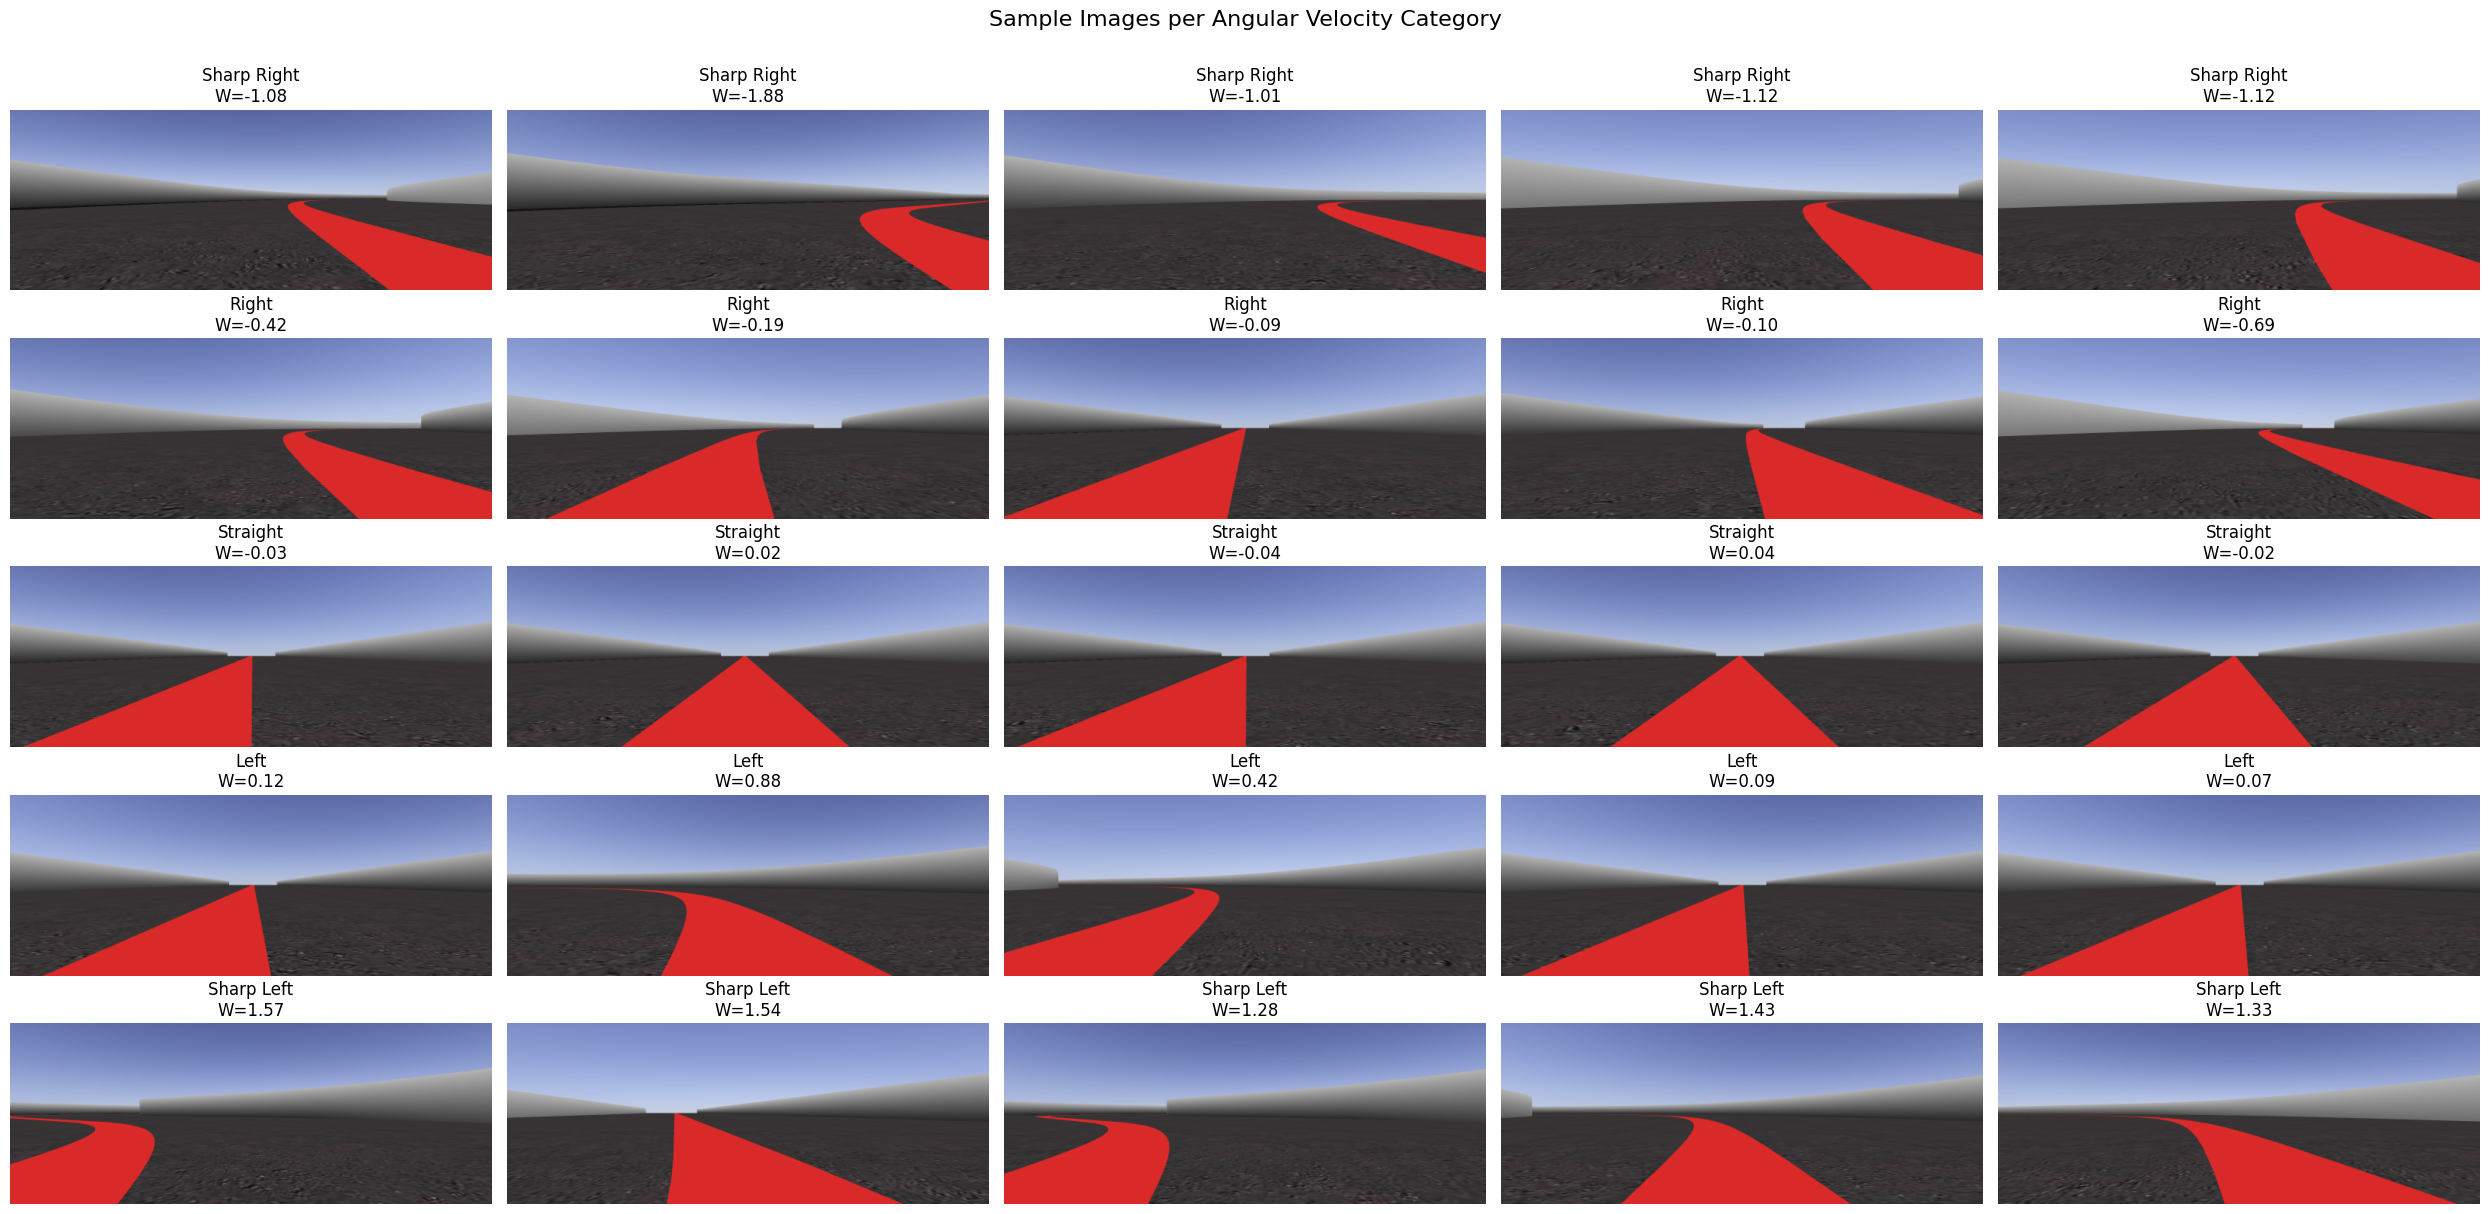

In [71]:
df = df_montmelo_circuit
# Create subplots
fig, axes = plt.subplots(len(labels), SAMPLES_PER_CATEGORY, figsize=(SAMPLES_PER_CATEGORY*5, len(labels)*2.5))
fig.suptitle("Sample Images per Angular Velocity Category", fontsize=16)

# Loop through each category
for row_idx, category in enumerate(labels):
    # Get random N samples from this category
    samples = df[df['w_category'] == category].sample(min(SAMPLES_PER_CATEGORY, df['w_category'].value_counts().get(category, 0)))

    for col_idx, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join("image_path", row['image'])
        # print(img_path)
        # continue

        # Read and resize image
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMAGE_SIZE)

            ax = axes[row_idx, col_idx] if SAMPLES_PER_CATEGORY > 1 else axes[row_idx]
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(f"{category}\nW={row['w']:.2f}")
        else:
            print(f"Image not found: {img_path}")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("angular_velocity_category_image_samples.png")
plt.show()


In [1]:
CIRCUIT_EPOCH_NUMBERS = {
    "simple_circuit":8,
    "montmelo_circuit":8, 
    "nurburgring_circuit":3,
    "montreal_circuit":5 
}
CIRCUIT_EPOCH_NUMBERS["simple_circuit"]

8